## Homework 8

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

### 1. Load, encode, and split off the test set

In [3]:
df = pd.read_excel('../data_manufacturing.xlsx')
y = df['Dissolution'].values
X_df = df.drop(columns=['Dissolution'])

# Same as previously in Homework 6 and 7
string_col_indices = [i for i, c in enumerate(X_df.columns)
                      if X_df[c].dtype == object or str(X_df[c].dtype) == 'str']
pre = ColumnTransformer(
    [('ohe', OneHotEncoder(drop='first', sparse_output=False), string_col_indices)],
    remainder='passthrough')
X = pre.fit_transform(X_df)

# Hold out 10% as an independent test set
X_trval, X_test, y_trval, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42)
print(f'train+val: {X_trval.shape[0]} samples,  test: {X_test.shape[0]} samples')

train+val: 81 samples,  test: 9 samples


### 2. Model pipeline

SVR is not scale-invariant, which means the RBF kernel and the regularisation both depend on feature scale, so `StandardScaler` is wrapped in the pipeline. The tube width ε is expressed in units of the target, so the target is standardised too via `TransformedTargetRegressor`. This makes the ε grid (0.01–0.5) interpretable as fractions of a target standard deviation.

In [ ]:
# scale X inside the pipeline and scale y via the wrapper so epsilon is in std-units of y
base = Pipeline([('sc', StandardScaler()), ('svr', SVR())])
model = TransformedTargetRegressor(regressor=base, transformer=StandardScaler())

### 3. Cross-validated grid search

We search over three kernels and the key hyperparameters. Scoring is negative MAE.

In [5]:
grid = {
    'regressor__svr__kernel':  ['linear', 'rbf', 'poly'],
    'regressor__svr__C':       [0.1, 1, 10, 100],
    'regressor__svr__epsilon': [0.01, 0.1, 0.2, 0.5],
    'regressor__svr__gamma':   ['scale', 0.01, 0.1],   # used by rbf/poly
}
gs = GridSearchCV(model, grid, cv=5,
                  scoring='neg_mean_absolute_error', n_jobs=-1)
gs.fit(X_trval, y_trval)

best = {k.split('__')[-1]: v for k, v in gs.best_params_.items()}
print('Best hyperparameters:', best)
print(f'Best CV MAE = {-gs.best_score_:.4f}')

Best hyperparameters: {'C': 10, 'epsilon': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV MAE = 0.9810


### 4. Tuning results

#### 4.1 Best CV score per kernel

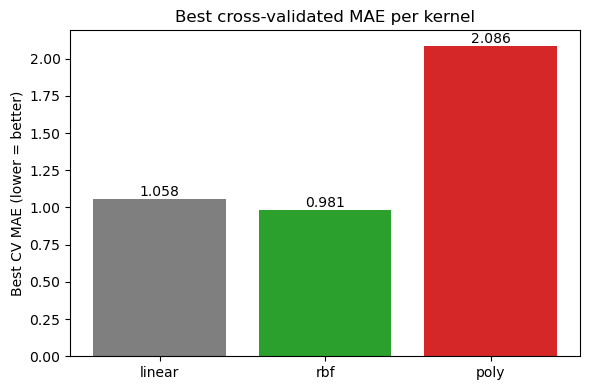

{'linear': np.float64(1.0582093499545513), 'rbf': np.float64(0.9809904969655117), 'poly': np.float64(2.085534516286625)}


In [6]:
res = pd.DataFrame(gs.cv_results_)
kernels = ['linear', 'rbf', 'poly']
best_per_kernel = {k: -res[res['param_regressor__svr__kernel'] == k]['mean_test_score'].max()
                   for k in kernels}

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(best_per_kernel.keys(), best_per_kernel.values(),
       color=['tab:gray', 'tab:green', 'tab:red'])
ax.set_ylabel('Best CV MAE (lower = better)')
ax.set_title('Best cross-validated MAE per kernel')
for i, v in enumerate(best_per_kernel.values()):
    ax.text(i, v, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(best_per_kernel)

#### 4.2 C–ε heatmap for the best kernel (RBF)

Holding `gamma` at its best value, we show how CV MAE varies over the C × ε grid.

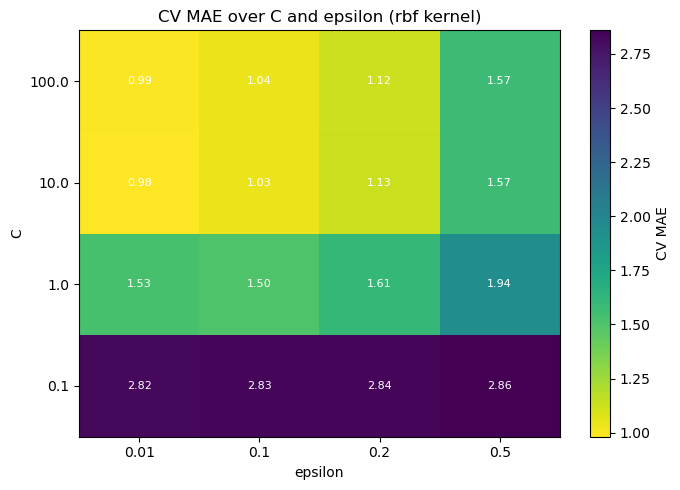

In [ ]:
best_kernel = best['kernel']
best_gamma  = gs.best_params_['regressor__svr__gamma']
mask = ((res['param_regressor__svr__kernel'] == best_kernel) &
        (res['param_regressor__svr__gamma'] == best_gamma))
sub = res[mask]

pivot = sub.pivot_table(index='param_regressor__svr__C',
                        columns='param_regressor__svr__epsilon',
                        values='mean_test_score').astype(float) * -1  # MAE

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='viridis_r', origin='lower')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
ax.set_xlabel('epsilon'); ax.set_ylabel('C')
ax.set_title(f'CV MAE over C and epsilon ({best_kernel} kernel)')
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f'{pivot.values[i, j]:.2f}', ha='center', va='center',
                color='white', fontsize=8)
fig.colorbar(im, label='CV MAE'); plt.tight_layout(); plt.show()

#### 4.3 Effect of C

Fixing ε and gamma at their best values, we sweep C and record CV MAE and the fraction of points that become support vectors (points on or outside the tube).

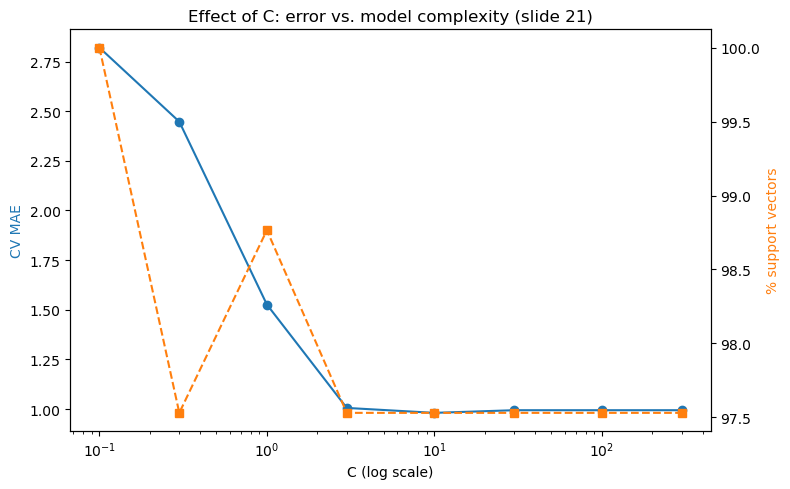

In [9]:
C_range = [0.1, 0.3, 1, 3, 10, 30, 100, 300]
mae_c, sv_frac = [], []
for C in C_range:
    m = TransformedTargetRegressor(
        regressor=Pipeline([('sc', StandardScaler()),
                            ('svr', SVR(kernel=best_kernel, C=C,
                                        epsilon=gs.best_params_['regressor__svr__epsilon'],
                                        gamma=best_gamma))]),
        transformer=StandardScaler())
    mae_c.append(-cross_val_score(m, X_trval, y_trval, cv=5,
                                  scoring='neg_mean_absolute_error').mean())
    m.fit(X_trval, y_trval)
    n_sv = m.regressor_.named_steps['svr'].support_.shape[0]
    sv_frac.append(100 * n_sv / len(y_trval))

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.semilogx(C_range, mae_c, 'o-', color='tab:blue', label='CV MAE')
ax1.set_xlabel('C (log scale)'); ax1.set_ylabel('CV MAE', color='tab:blue')
ax2 = ax1.twinx()
ax2.semilogx(C_range, sv_frac, 's--', color='tab:orange')
ax2.set_ylabel('% support vectors', color='tab:orange')
plt.title('Effect of C: error vs. model complexity (slide 21)')
plt.tight_layout(); plt.show()

### 5. Final evaluation on the independent test set

`GridSearchCV` has already refit the best configuration on the full 90 %. We now evaluate it once on the untouched test set.

In [11]:
y_test_hat = gs.predict(X_test)
print(f'TEST  RMSE = {root_mean_squared_error(y_test, y_test_hat):.4f}')
print(f'TEST  MAE  = {mean_absolute_error(y_test, y_test_hat):.4f}')
print(f'TEST  R^2  = {r2_score(y_test, y_test_hat):.4f}')

TEST  RMSE = 0.9561
TEST  MAE  = 0.8204
TEST  R^2  = 0.9160


### 6. Discussion

#### Tuning outcome
The cross-validation selected an RBF Kernel with C = 10, ε = 0.01, γ = 0.01 (best CV MAE ≈ 0.98). Across kernels:

| Kernel | Best CV MAE |
|---|---|
| RBF | ≈ 0.98 |
| Linear | ≈ 1.06 |
| Polynomial | ≈ 2.09 |

RBF edges out the linear kernel only slightly, which tells us the Dissolution response is close to linear in the features, meaning there is mild nonlinearity that RBF captures, but not much. The polynomial kernel does significantly worse: with 19 features it tends to over- or undershoot badly.

#### Effect of the hyperparameters
- C: the MAE-vs-C curve decreases and then flattens. The percentage of support vectors rises with C as the model lets more points influence the fit. Beyond C ≈ 10 there is little gain, meaning larger C only risks fitting noise (more variance).
- ε: the optimum sits at a small ε (0.01), i.e. a narrow tube. This means almost all points carry information and few are "ignored".

#### Performance and comparison
On the independent test set the tuned SVR reaches RMSE ≈ 0.96, MAE ≈ 0.82, R² ≈ 0.92. This is essentially matching OLS (from exercise 3, R² ≈ 0.92) and the LASSO test result (from exercise 7, RMSE ≈ 1.05–1.08), and on this particular split slightly better in RMSE. All three methods land in the same accuracy range, meaning SVR's flexibility buys little here because the underlying relationship is largely linear.

#### Limitations
- The test set is only 9 samples, so the single test RMSE is noisy. The close ranking of SVR vs. LASSO vs. OLS should not be over-interpreted from one split.
- SVR has no interpretability, unlike the OLS/LASSO coefficients. For this dataset, where OLS already fits well and offers interpretable, significance-tested coefficients, SVR's main contribution is confirming that a flexible nonlinear model does not substantially beat the linear one and thus shows evidence that the linear model is adequate.